In [1]:
!kaggle datasets download prasad22/healthcare-dataset

Dataset URL: https://www.kaggle.com/datasets/prasad22/healthcare-dataset
License(s): CC0-1.0
100% 2.91M/2.91M [00:00<00:00, 208MB/s]



In [2]:
!unzip healthcare-dataset.zip
!ls

Archive:  healthcare-dataset.zip
  inflating: healthcare_dataset.csv  
healthcare_dataset.csv	healthcare-dataset.zip	sample_data


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import category_encoders as ce

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
df = pd.read_csv("healthcare_dataset.csv")
df.head(2)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [7]:
df.describe(include="all")

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


In [12]:
df.shape

(55500, 15)

**EDA**

<Axes: xlabel='Test Results'>

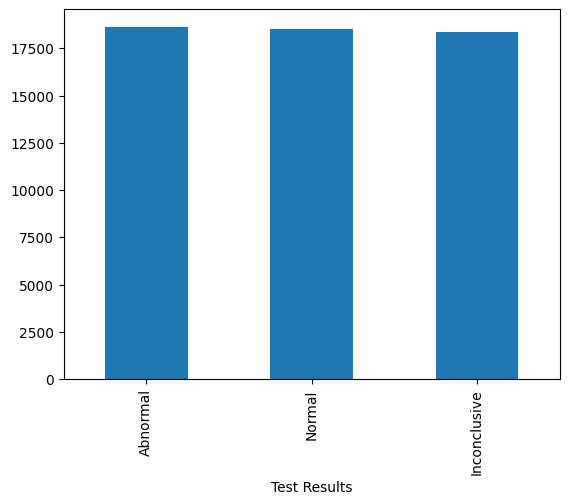

In [8]:
df["Test Results"].value_counts().plot(kind='bar')

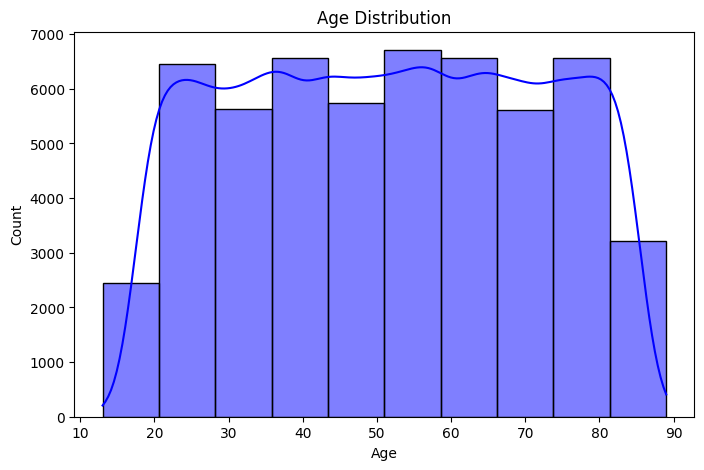

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=10, kde=True, color="blue")
plt.title('Age Distribution')
plt.show()

/tmp/ipykernel_5920/2135121655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Test Results', y='Billing Amount', palette='Set2')


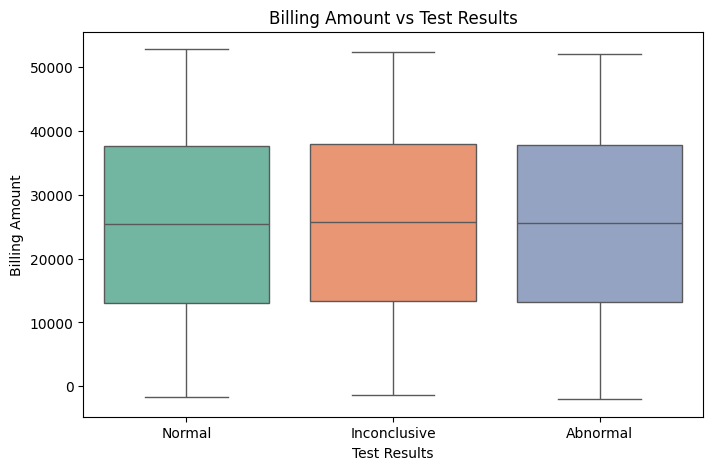

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Test Results', y='Billing Amount', palette='Set2')
plt.title('Billing Amount vs Test Results')
plt.show()

**Data Preprocessing**

In [16]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length_of_Stay_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

cols_drop = ['Name', 'Room Number', 'Date of Admission', 'Discharge Date']
df = df.drop(columns=cols_drop)

In [17]:
x = df.drop(columns=["Test Results"])
y = df['Test Results']

In [21]:
le = LabelEncoder()
y = le.fit_transform(y)

In [18]:
admission_mapping = {'Elective': 0, 'Urgent': 1, 'Emergency': 2}
x['Admission Type'] = x['Admission Type'].map(admission_mapping)

In [19]:
x = pd.get_dummies(x, columns=['Gender', 'Blood Type', 'Medical Condition'], drop_first=True, dtype=int)

In [22]:
high_card_cols = ['Doctor', 'Hospital', 'Insurance Provider', 'Medication']

target_encoder = ce.TargetEncoder(cols=high_card_cols)
x[high_card_cols] = target_encoder.fit_transform(x[high_card_cols], y)

In [25]:
final_df = pd.concat([pd.DataFrame(x), pd.Series(y, name='Target')], axis=1)

print(final_df.shape)
final_df.head(2)

(55500, 22)


,Age,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Medication,Length_of_Stay_Days,Gender_Male,Blood Type_A-,...,Blood Type_B+,Blood Type_B-,Blood Type_O+,Blood Type_O-,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Hypertension,Medical Condition_Obesity,Target
0,30,1.199124,0.998442,1.004612,18856.281306,1,0.992413,2,1,0,...,0,1,0,0,0,1,0,0,0,2
1,62,0.998276,0.932471,0.994083,33643.327287,2,0.998922,6,1,0,...,0,0,0,0,0,0,0,0,1,1
